In [1]:
import scanpy as sc
import anndata as ad
import pandas as pd

In [2]:
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=80,dpi_save=100,color_map='Reds')
sc.logging.print_version_and_date()

import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib
plt.show()
matplotlib.rcParams.update({'figure.figsize': (6,6)})

Running Scanpy 1.10.3, on 2025-09-01 11:55.


In [3]:
samples = {
    "ko_d6": "/mnt/yiming/public/for_yiming_troy_0830/k6_filter_feature.h5ad",
    "ko_d8": "/mnt/yiming/public/for_yiming_troy_0830/k8_filter_feature.h5ad", 
    "wt_d4": "/mnt/yiming/public/for_yiming_troy_0830/w4_filter_feature.h5ad",
    "wt_d8": "/mnt/yiming/public/for_yiming_troy_0830/w8_filter_feature.h5ad"
}

adatas = {}

for sample_id, file_path in samples.items():
    adata = sc.read_h5ad(file_path)
    adata.var_names_make_unique()
    
    adata.obs['sample'] = sample_id
    adata.obs['group'] = 'KO' if 'ko' in sample_id else 'WT'
    adata.obs['day'] = int(sample_id.split('_d')[1])
    
    adatas[sample_id] = adata

print(adatas)

{'ko_d6': AnnData object with n_obs × n_vars = 13754 × 32205
    obs: 'sample', 'group', 'day'
    var: 'gene_symbols', 'ko_d8': AnnData object with n_obs × n_vars = 7214 × 32372
    obs: 'sample', 'group', 'day'
    var: 'gene_symbols', 'wt_d4': AnnData object with n_obs × n_vars = 8487 × 32858
    obs: 'sample', 'group', 'day'
    var: 'gene_symbols', 'wt_d8': AnnData object with n_obs × n_vars = 6185 × 32637
    obs: 'sample', 'group', 'day'
    var: 'gene_symbols'}


In [4]:
adatas['ko_d6'].obs

,sample,group,day
CELL2_N2,ko_d6,KO,6
CELL3_N3,ko_d6,KO,6
CELL6_N2,ko_d6,KO,6
CELL9_N5,ko_d6,KO,6
CELL10_N4,ko_d6,KO,6
...,...,...,...
CELL69359_N1,ko_d6,KO,6
CELL69361_N1,ko_d6,KO,6
CELL69364_N1,ko_d6,KO,6
CELL69365_N1,ko_d6,KO,6


In [5]:
for sample_id, file_path in samples.items():
    adatas[sample_id].var["mt"] = adatas[sample_id].var_names.str.startswith("MT-") 
    sc.pp.calculate_qc_metrics(adatas[sample_id], qc_vars=["mt"], inplace=True, log1p=True)

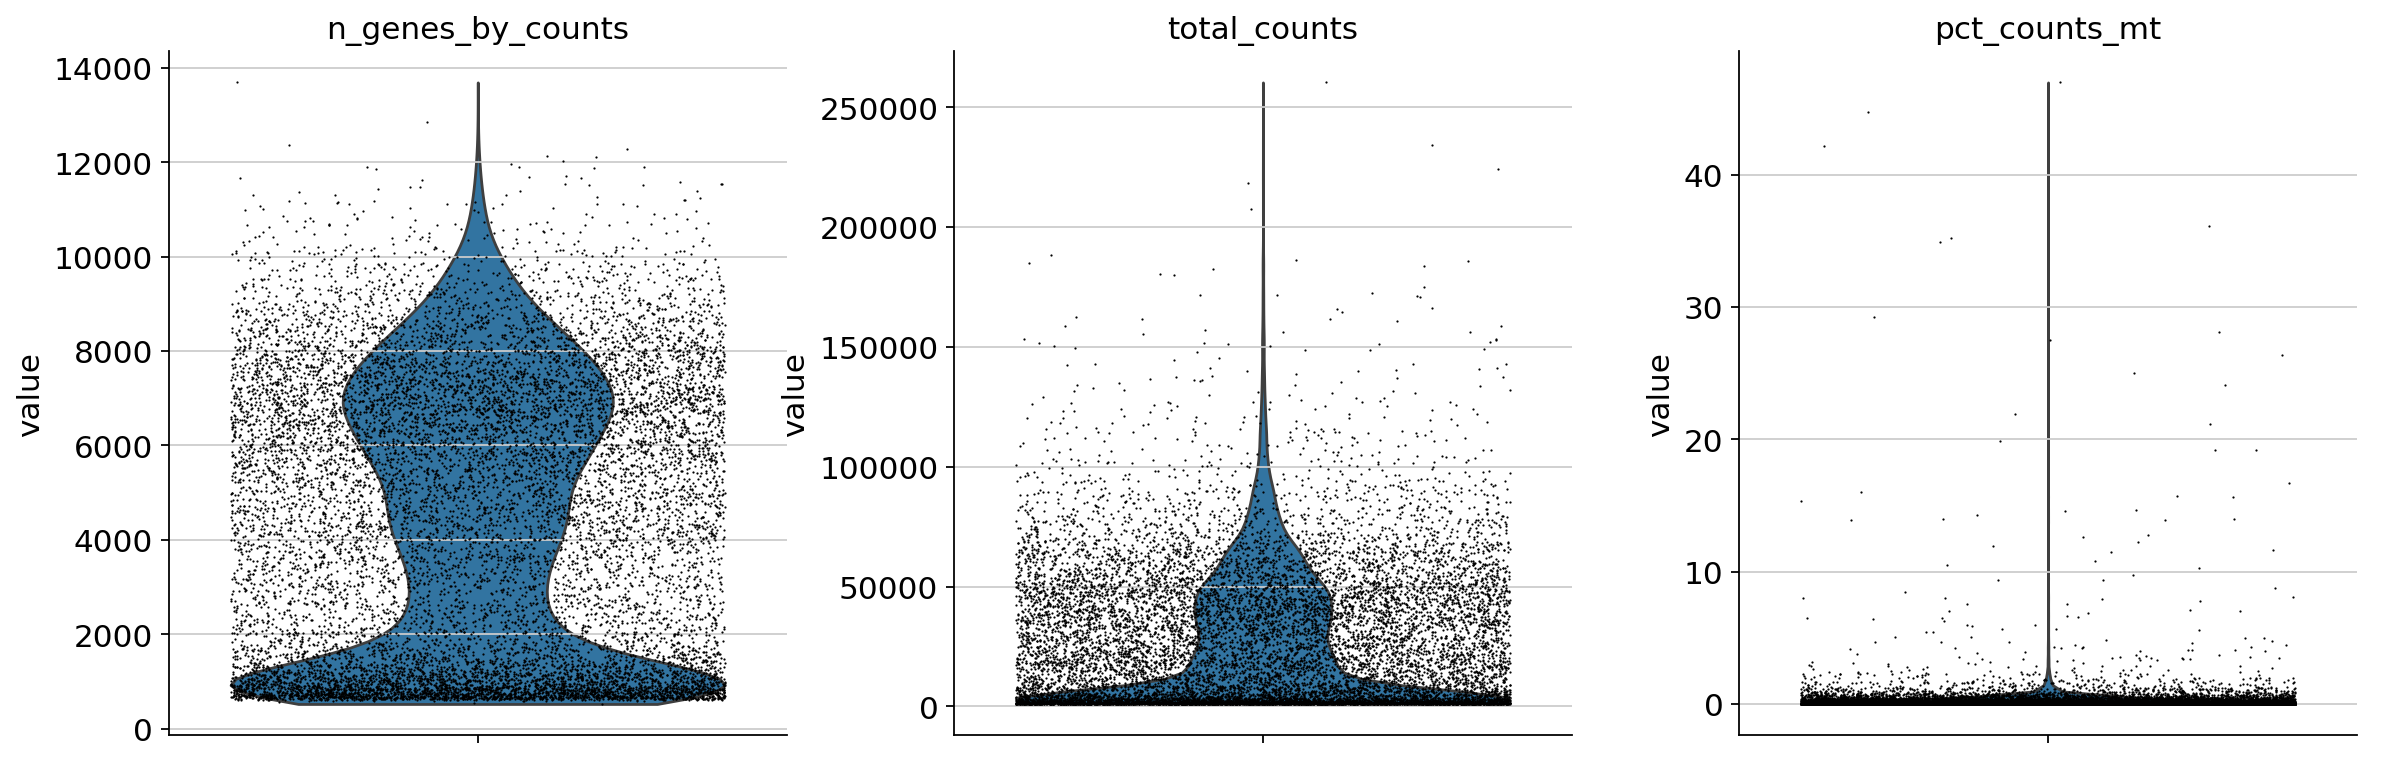

In [6]:
sample = 'ko_d6'

sc.pl.violin(adatas[sample],
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,)

In [7]:
# Filter cells and genes
sc.pp.filter_cells(adatas[sample], min_genes=100)
sc.pp.filter_genes(adatas[sample], min_cells=3)

# Define filters
cell_filter = (adatas[sample].obs.n_genes_by_counts < 10000) & \
              (adatas[sample].obs.total_counts < 120000) & \
              (adatas[sample].obs.pct_counts_mt < 5)

# Apply filters
adatas[sample] = adatas[sample][cell_filter, :].copy()

adatas[sample]

filtered out 2853 genes that are detected in less than 3 cells


AnnData object with n_obs × n_vars = 13454 × 29352
    obs: 'sample', 'group', 'day', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'gene_symbols', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'

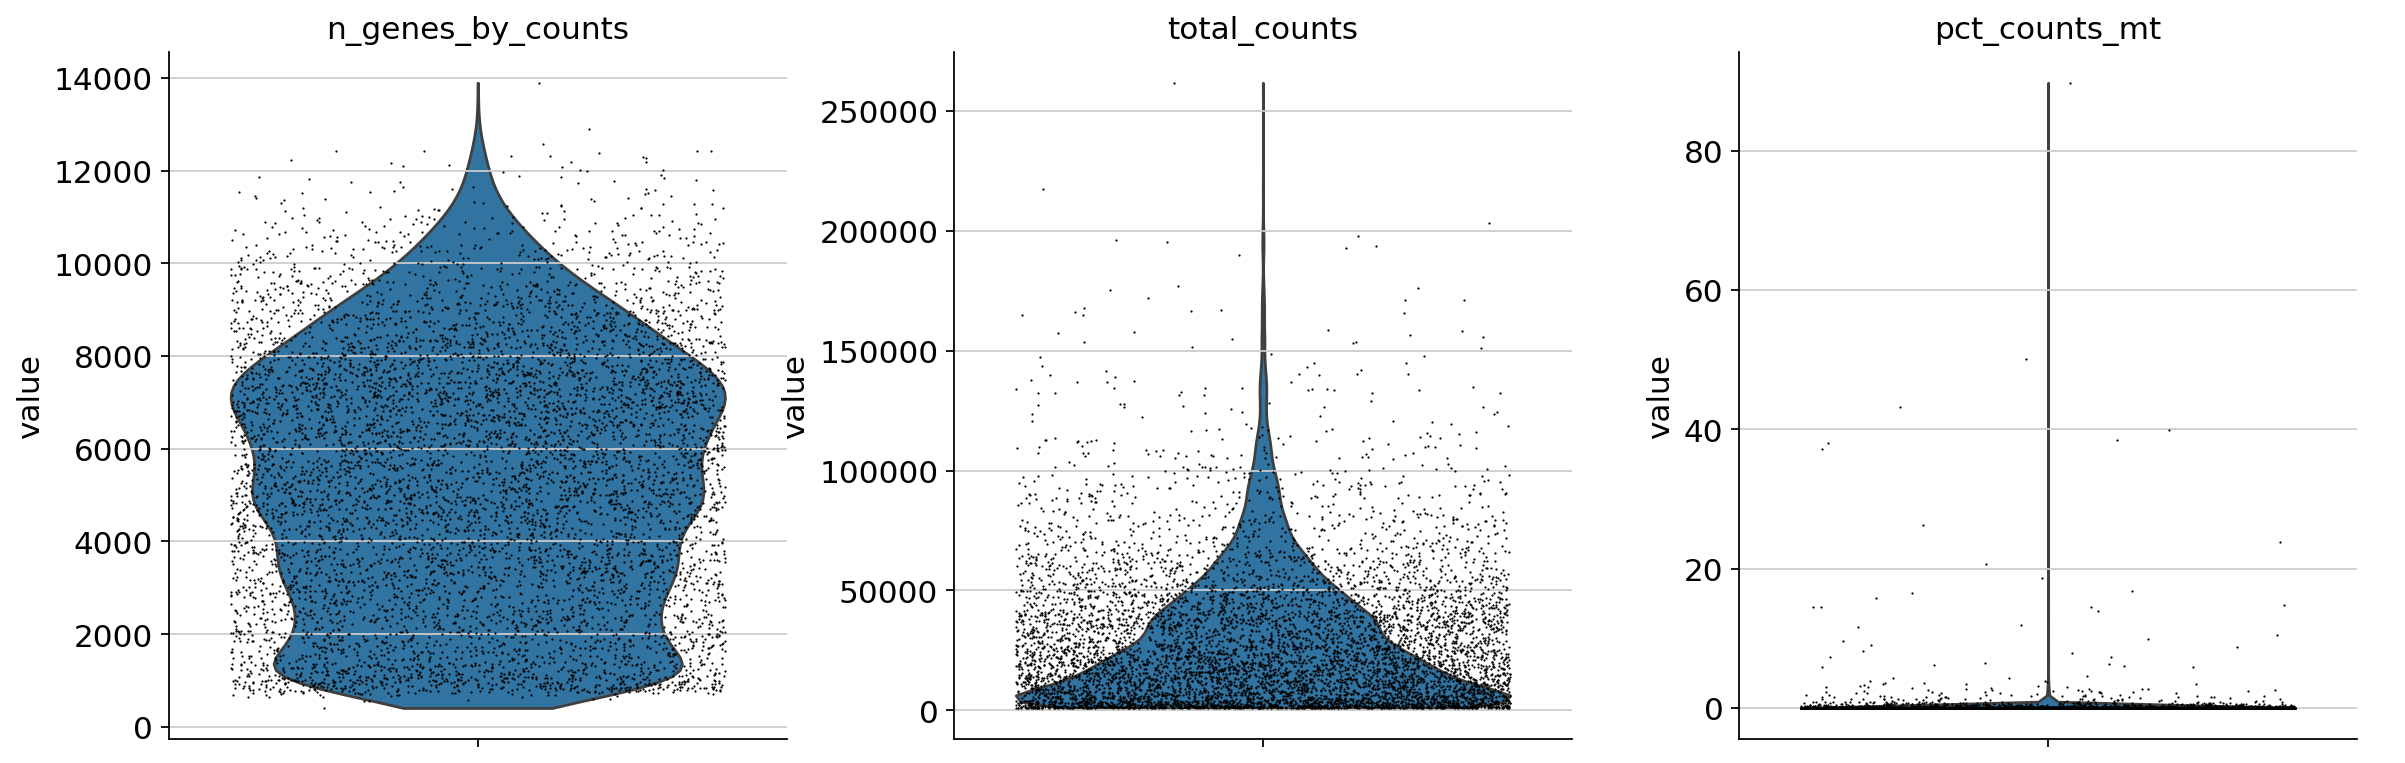

In [8]:
sample = 'ko_d8'

sc.pl.violin(adatas[sample],
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,)

In [9]:
# Filter cells and genes
sc.pp.filter_cells(adatas[sample], min_genes=100)
sc.pp.filter_genes(adatas[sample], min_cells=3)

# Define filters
cell_filter = (adatas[sample].obs.n_genes_by_counts < 10000) & \
              (adatas[sample].obs.total_counts < 100000) & \
              (adatas[sample].obs.pct_counts_mt < 5)

# Apply filters
adatas[sample] = adatas[sample][cell_filter, :].copy()

adatas[sample]

filtered out 2848 genes that are detected in less than 3 cells


AnnData object with n_obs × n_vars = 6851 × 29524
    obs: 'sample', 'group', 'day', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'gene_symbols', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'

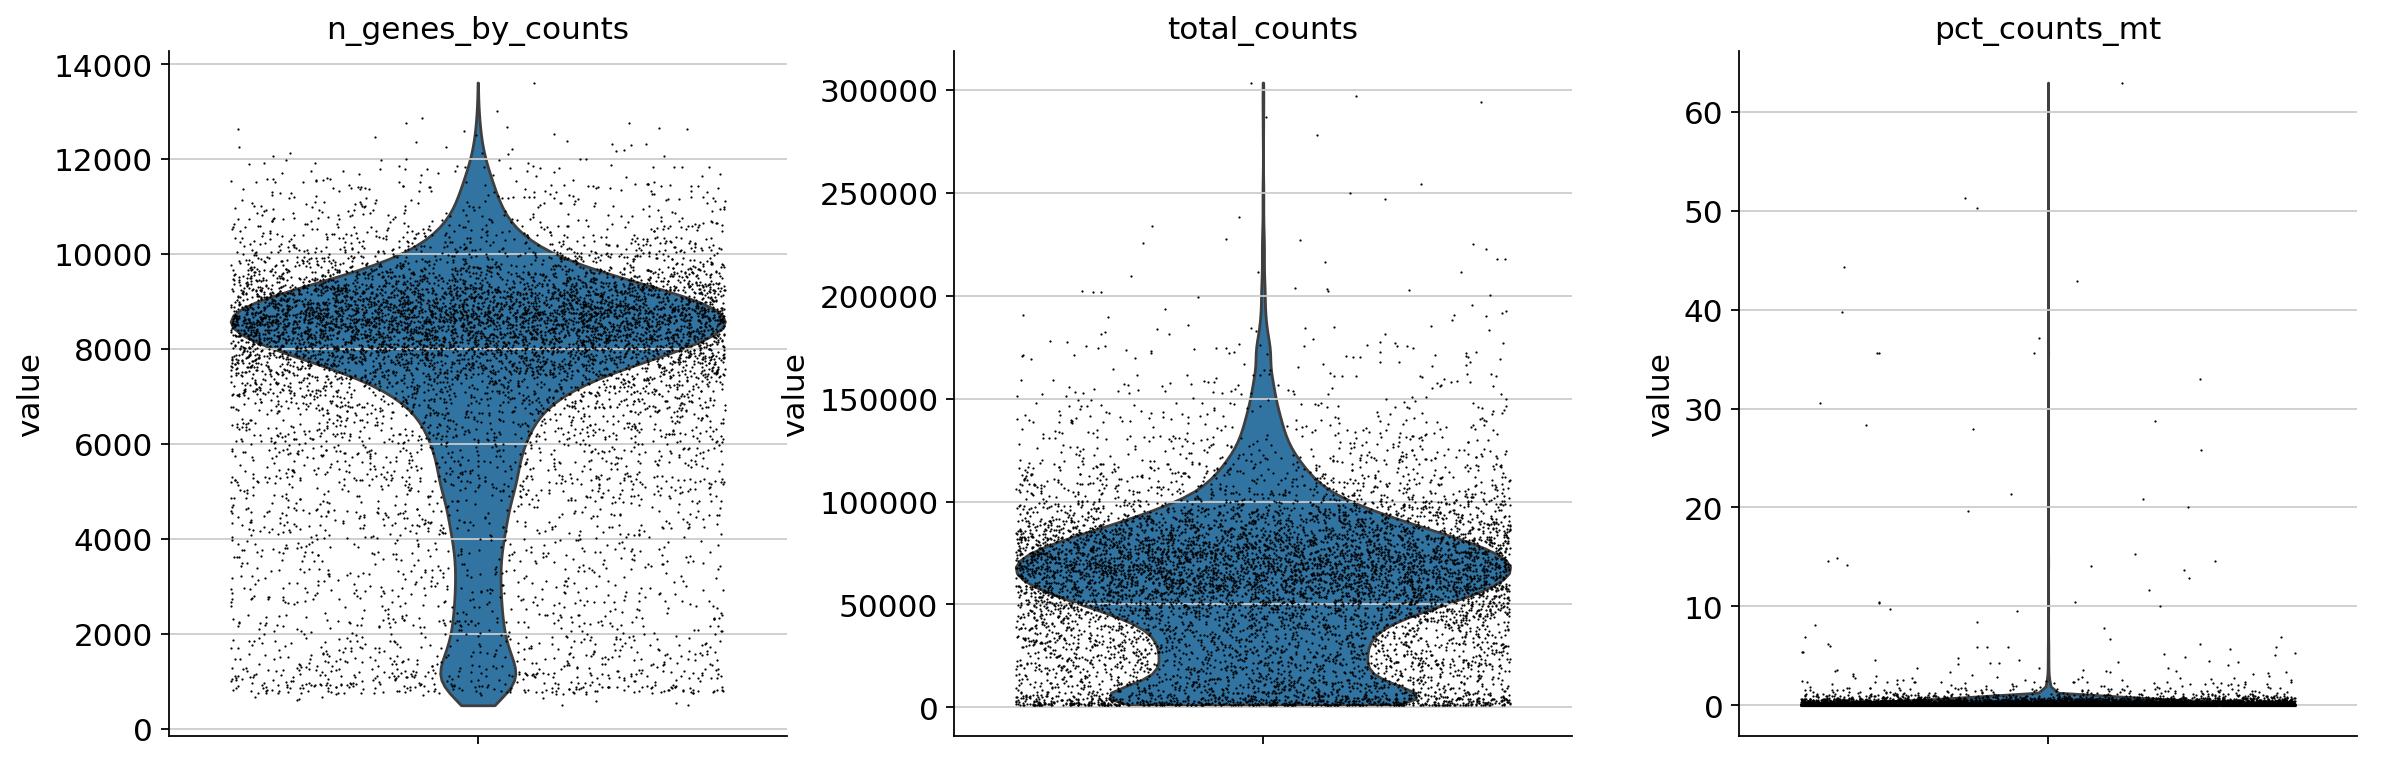

In [10]:
sample = 'wt_d4'

sc.pl.violin(adatas[sample],
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,)

In [11]:
# Filter cells and genes
sc.pp.filter_cells(adatas[sample], min_genes=100)
sc.pp.filter_genes(adatas[sample], min_cells=3)

# Define filters
cell_filter = (adatas[sample].obs.n_genes_by_counts < 11000) & \
(adatas[sample].obs.n_genes_by_counts > 5000) & \
              (adatas[sample].obs.total_counts < 120000) & \
              (adatas[sample].obs.pct_counts_mt < 5)

# Apply filters
adatas[sample] = adatas[sample][cell_filter, :].copy()

adatas[sample]

filtered out 2645 genes that are detected in less than 3 cells


AnnData object with n_obs × n_vars = 6681 × 30213
    obs: 'sample', 'group', 'day', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'gene_symbols', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'

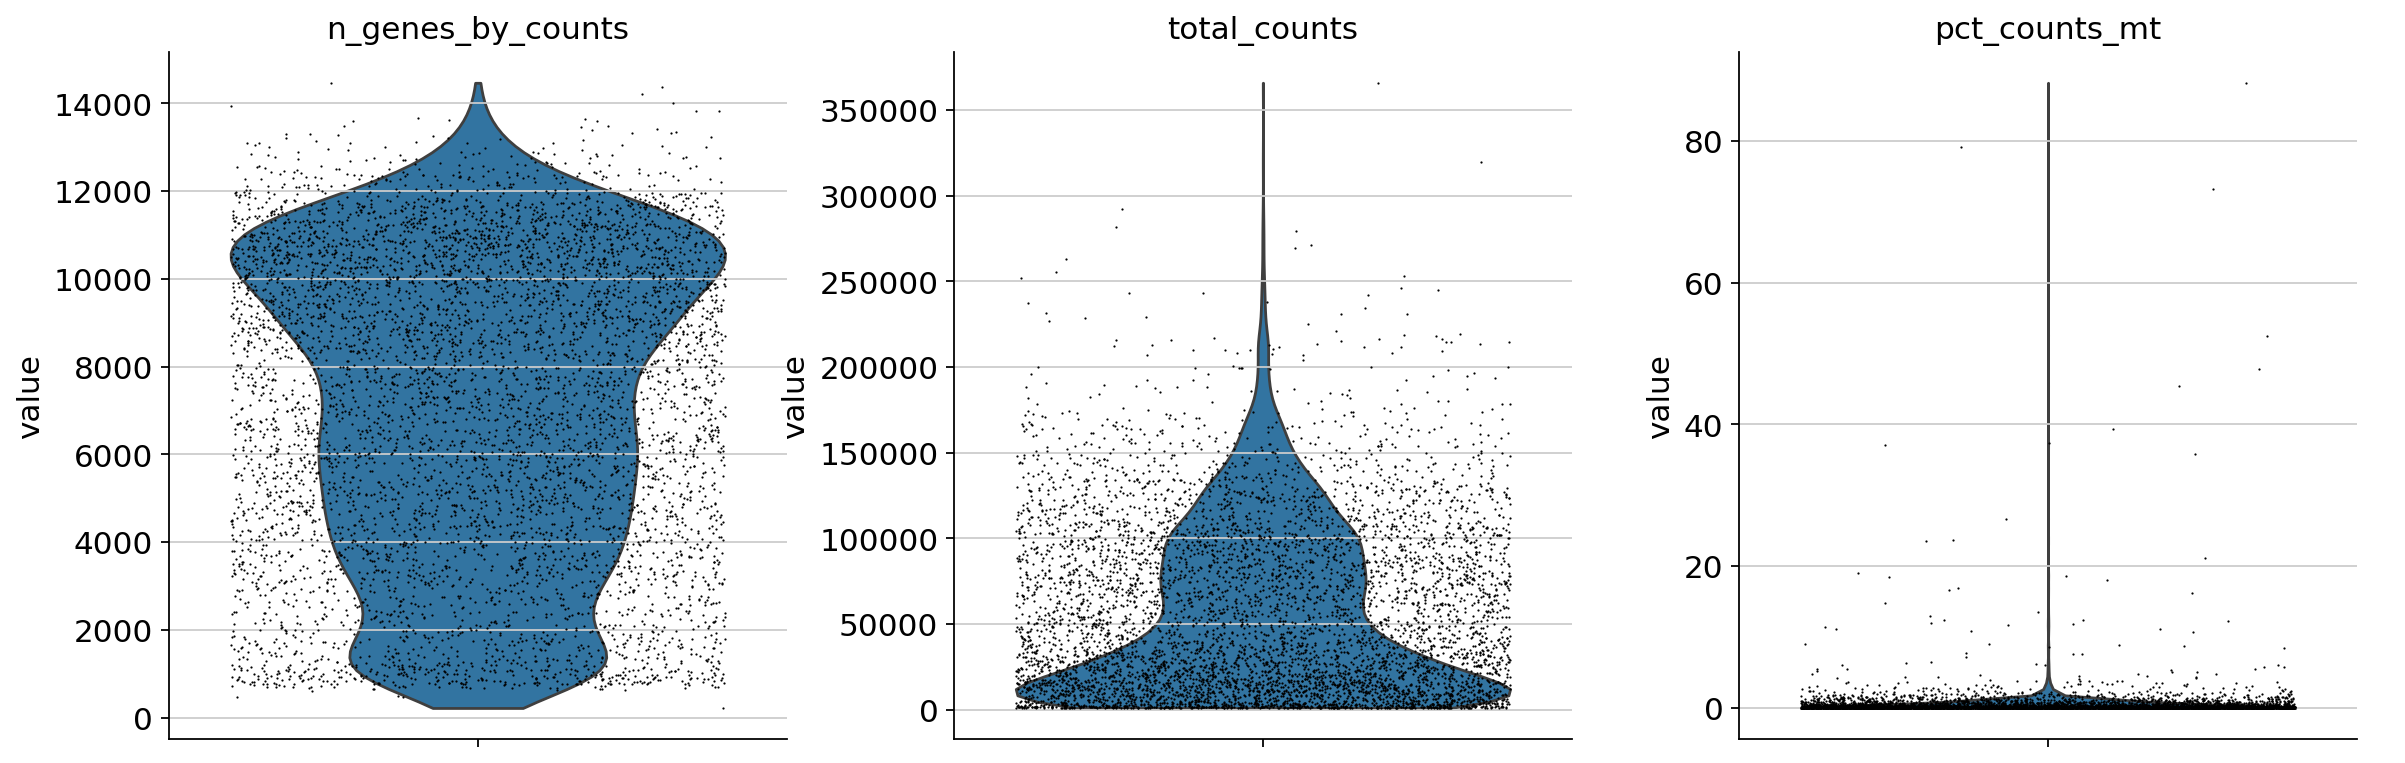

In [12]:
sample = 'wt_d8'

sc.pl.violin(adatas[sample],
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,)

In [13]:
# Filter cells and genes
sc.pp.filter_cells(adatas[sample], min_genes=100)
sc.pp.filter_genes(adatas[sample], min_cells=3)

# Define filters
cell_filter = (adatas[sample].obs.n_genes_by_counts < 12000) & \
              (adatas[sample].obs.total_counts < 150000) & \
              (adatas[sample].obs.pct_counts_mt < 5)

# Apply filters
adatas[sample] = adatas[sample][cell_filter, :].copy()

adatas[sample]

filtered out 2384 genes that are detected in less than 3 cells


AnnData object with n_obs × n_vars = 5797 × 30253
    obs: 'sample', 'group', 'day', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'gene_symbols', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'

In [14]:
adatas

{'ko_d6': AnnData object with n_obs × n_vars = 13454 × 29352
     obs: 'sample', 'group', 'day', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes'
     var: 'gene_symbols', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells',
 'ko_d8': AnnData object with n_obs × n_vars = 6851 × 29524
     obs: 'sample', 'group', 'day', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes'
     var: 'gene_symbols', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_coun

In [15]:
adata = ad.concat(adatas, label="sample")

/mnt/yiming/nfs_share/anaconda3/envs/scanpy/lib/python3.11/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [16]:
adata.obs_names_make_unique()

In [17]:
sc.pp.scrublet(adata, batch_key="sample")

Running Scrublet
filtered out 89 genes that are detected in less than 3 cells
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:01)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
Embedding transcriptomes using PCA...
    using data matrix X directly
Automatically set threshold at doublet score = 0.51
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 0.0%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 0.0%
filtered out 194 genes that are detected in less than 3 cells
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var

In [18]:
adata

AnnData object with n_obs × n_vars = 32783 × 27502
    obs: 'sample', 'group', 'day', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet'
    uns: 'scrublet'

In [19]:
adata = adata[adata.obs['predicted_doublet'] == False]

In [20]:
adata

View of AnnData object with n_obs × n_vars = 32780 × 27502
    obs: 'sample', 'group', 'day', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet'
    uns: 'scrublet'

In [9]:
adata.write_h5ad('/mnt/yiming/nfs_share/hema_wave/perigas-bgi-rna.h5ad')